# Ask

## Scenario: 

>"We have customer ratings and review data for over 1,000 products. We're spending a lot on discounts, but we're not sure if discounting is actually making customers happier or driving better ratings. We also don't know which product categories are performing best. Can you look into this for us?"

## Business questions

| # | Business Question | Why It Matters |
| :-- | :--- | :--- |
| 1 | Does a higher discount percentage lead to a higher product rating? | Helps decide if deep discounting is worth the margin loss |
| 2 | Which product categories have the highest average ratings? | Identifies Amazon's strongest and weakest performing verticals |
| 3 | Are heavily discounted products reviewed more frequently? | Determines if discounts drive customer engagement |
| 4 | What is the relationship between actual price and customer rating? | Reveals if price perception affects satisfaction |
| 5 | Which categories receive the most customer reviews (rating count)? | Highlights where customers are most engaged |

# Prepare

## Data Evaluation

- **Reliable**: Low -> Single snapshot, no clear collection methodology stated
- **Original**: Low -> Scraped from Amazon's website
- **Comprehensive**: High -> Has prices, discounts, ratings, reviews, and categories
- **Current**: Low -> Published Jan 2023 (May not reflect today's market)
- **Cited**: High -> Source is publicly documented on Kaggle

## Data Scope

| Column | Type | Relevant? | Note |
| :--- | :--- | :---: | :--- |
| **product_id** | ID | [x] | Unique identifier |
| **product_name** | Text | [x] | For context/labeling |
| **category** | Text | [x] | Key analysis column |
| **discounted_price** | Numeric (text) | [x] | Key analysis column |
| **actual_price** | Numeric (text) | [x] | Key analysis column |
| **discount_percentage** | Numeric (text) | [x] | Key analysis column |
| **rating** | Numeric (text) | [x] | Key analysis column |
| **rating_count** | Numeric (text) | [x] | Key analysis column |
| **about_product** | Long Text | [ ] | Skip for now |
| **user_id** | ID | [ ] | Not needed for our questions |
| **user_name** | Text | [ ] | Not needed |
| **review_id** | ID | [ ] | Not needed |
| **review_title** | Text | [ ] | Skip for now |
| **review_content** | Long Text | [ ] | Skip for now |
| **img_link** | URL | [ ] | Not needed |
| **product_link** | URL | [ ] | Not needed |

## Data Info
- Data source: Kaggle — Amazon Sales Dataset by [KARKAVELRAJA J](https://www.kaggle.com/karkavelrajaj)
- License: CC BY-NC-SA 4.0
- Dataset size: ~1,465 rows × 16 columns
- Key columns for analysis: category, discounted_price, actual_price, 
  discount_percentage, rating, rating_count
- Anticipated issues: currency symbols, % signs, text-type numerics, 
  hierarchical categories
- Limitations: static snapshot (Jan 2023), scraped data (not official)
- Note: Currency symbol in `₹` Indian Rupee (INR)

# Process

## Steps Overview
1. Pre-cleaning inspection  
1.1 Package prep: `import` NumPy, pandas, matplotlib, seaborn, etc.  
1.2 Data loading     
1.3 File management (`pathlib`)  
1.4 Data inspection (first_look func)
2. Data cleaning  
2.1 Clean column names  
2.2 Remove irrelevant columns/scope  
2.3 Remove duplicate  
2.4 Fix data types  
2.5 Standardizing   
2.6 Handle missing values  
2.7 Handle outliers  
2.8 Validate  
2.9 Final QA and save  

In [3]:
# 1.1 Package prep
import numpy as np  
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings # Keep logs clean

warnings.filterwarnings('ignore', category=UserWarning)

In [ ]:
# 1.2 Data loading

import kagglehub
import shutil
from pathlib import Path

# --- Download from Kaggle ---
download_path = kagglehub.dataset_download('karkavelrajaj/amazon-sales-dataset')
print(f"Downloaded to cache: {download_path}")

# 1.3 File management

# --- Define project paths ---
base_dir = Path.cwd()
raw_path = base_dir / 'data' / 'raw' / 'amazon.csv'
processed_path = base_dir / 'data' / 'processed' / 'amazon_clean.csv'

# --- Copy raw file into data/raw/ ---
source_file = Path(download_path) / 'amazon.csv'
shutil.copy(source_file, raw_path)
print(f"Raw file saved to: {raw_path}")

# --- Make a copy for cleaning (data/processed/) ---
shutil.copy(raw_path, processed_path)
print(f"Working copy saved to: {processed_path}")

In [ ]:
# 1.4 Data inspection

df = pd.read_csv(processed_path)

def first_look(df):
    print(f"Shape: {df.shape}")
    print(f"\nColumn types:\n{df.dtypes}")
    print(f"\nMissing values (%):\n{(df.isnull().mean() * 100).round(1)}")
    print(f"\nDuplicates: {df.duplicated().sum()}")
    print(f"\nBasic stats:\n{df.describe(include='all')}")
    print(f"\nFirst 5 rows:\n{df.head()}")

first_look(df)

Shape: (1465, 16)

Column types:
product_id             str
product_name           str
category               str
discounted_price       str
actual_price           str
discount_percentage    str
rating                 str
rating_count           str
about_product          str
user_id                str
user_name              str
review_id              str
review_title           str
review_content         str
img_link               str
product_link           str
dtype: object

Missing values (%):
product_id             0.0
product_name           0.0
category               0.0
discounted_price       0.0
actual_price           0.0
discount_percentage    0.0
rating                 0.0
rating_count           0.1
about_product          0.0
user_id                0.0
user_name              0.0
review_id              0.0
review_title           0.0
review_content         0.0
img_link               0.0
product_link           0.0
dtype: float64

Duplicates: 0

First 5 rows:
   product_id          

## Dtype Problems

|Column|Data Types|Expected Dtype|
|:---|:---|:---|
|product_id|`str`||
|product_name|`str`||
|category|`str`||
|discounted_price|`str`|`float`|
|actual_price|`str`|`float`|
|discount_percentage|`str`|`float`|
|rating|`str`|`float`|
|rating_count|`str`|`float`|
|about_product|`str`||
|user_id|`str`|`int`|
|user_name|`str`||
|review_id|`str`|`int`|
|review_title|`str`||
|review_content|`str`||
|img_link|`str`||
|product_link|`str`||

In [6]:
# 2.1 Clean column names

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns.tolist())

['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']


In [7]:
# 2.2 Remove irrelevant columns/scope

cols_to_keep = [
  'product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count'
]

df = df[cols_to_keep]

print(f"Shape after dropping irrelevant columns: {df.shape}")

Shape after dropping irrelevant columns: (1465, 8)


In [8]:
# 2.3 Remove duplicate

df = df.drop_duplicates(subset='product_id') # Drop only col that identifies business key
print(f"Shape after dropping duplicate columns: {df.shape}") 

Shape after dropping duplicate columns: (1351, 8)


In [9]:
# 2.4 Fix data types

df['discounted_price'] = df['discounted_price'].str.replace('₹', '').str.replace(',', '').astype(float)
df['actual_price'] = df['actual_price'].str.replace('₹', '').str.replace(',', '').astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '').astype(float)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = df['rating_count'].str.replace(',', '').astype(float)

df.dtypes

product_id                 str
product_name               str
category                   str
discounted_price       float64
actual_price           float64
discount_percentage    float64
rating                 float64
rating_count           float64
dtype: object

In [10]:
# 2.5 Standardizing

# Extract top-level category (e.g. "Computers&Accessories|Accessories&Peripherals|..." -> "Computer&Accessories")

df['main_category'] = df['category'].str.split('|').str[0].str.strip()

print(df['main_category'].value_counts())

main_category
Electronics              490
Home&Kitchen             448
Computers&Accessories    375
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64


In [11]:
# 2.6 Handle missing values

# Find the missing values
print(f"NULLs before:\n{df.isnull().sum()}")

# Drop rows where key analysis columns are NULL
df = df.dropna(subset=['rating', 'rating_count', 'discount_percentage'])

print(f"\nNULLs after:\n{df.isnull().sum()}")
print(f"Shape: {df.shape}") # Note: If 50% of rows gone -> file corrupt OR too strict subset

NULLs before:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 1
rating_count           2
main_category          0
dtype: int64

NULLs after:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
main_category          0
dtype: int64
Shape: (1348, 9)


In [12]:
# 2.7 Handle Outliers

# Find the outlier (Focus on Min/Max)
print(df[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']].describe())

       discounted_price   actual_price  discount_percentage       rating  \
count       1348.000000    1348.000000          1348.000000  1348.000000   
mean        3310.267188    5700.506395            46.662463     4.091988   
std         7180.901370   11229.356113            21.607716     0.295139   
min           39.000000      39.000000             0.000000     2.000000   
25%          349.000000     899.000000            31.000000     3.900000   
50%          899.000000    1795.000000            49.000000     4.100000   
75%         2184.000000    4592.500000            62.000000     4.300000   
max        77990.000000  139900.000000            94.000000     5.000000   

        rating_count  
count    1348.000000  
mean    17656.847923  
std     42158.843602  
min         2.000000  
25%      1107.500000  
50%      4740.000000  
75%     16051.500000  
max    426973.000000  


In [13]:
# Filter based on findings

df = df[df['rating'].between(1, 5)] # If > 5 and < 1 = invalid
df = df[df['discount_percentage'].between(0, 100)] # If over 100 = invalid
df = df[df['rating_count'] > 0] # If 0 = useless for analysis

print(f"Shape after outlier removed: {df.shape}")

Shape after outlier removed: (1348, 9)


Shape before (1348, 9) + Shape after (1348, 9) = No outlier

In [14]:
# 2.8 Validate

# Sanity checks
assert df['rating'].between(1, 5).all(), "Invalid ratings found!"
assert df['discount_percentage'].between(0, 100).all(), "Invalid discounts found!"
assert df['rating_count'].gt(0).all(), "Zero rating count found!"
assert df.duplicated(subset='product_id').sum() == 0, "Duplicates still exist"

print("🟢 Data is clean!")

🟢 Data is clean!


In [15]:
# 2.9 Final QA & Save

print(f"Final Shape: {df.shape}")
print(f"\nFinal Data types:\n{df.dtypes}")
print(f"\nMissing values:]\n{df.isnull().sum()}")

# save
df.to_csv(processed_path, index=False)
print("\n ✅ Cleaned dataset saved to data/processed/amazon_clean.csv")

Final Shape: (1348, 9)

Final Data types:
product_id                 str
product_name               str
category                   str
discounted_price       float64
actual_price           float64
discount_percentage    float64
rating                 float64
rating_count           float64
main_category           object
dtype: object

Missing values:]
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
main_category          0
dtype: int64

 ✅ Cleaned dataset saved to data/processed/amazon_clean.csv


# Analyze

## Q1 - Does higher discount lead to higher rating?

Correlation: -0.162


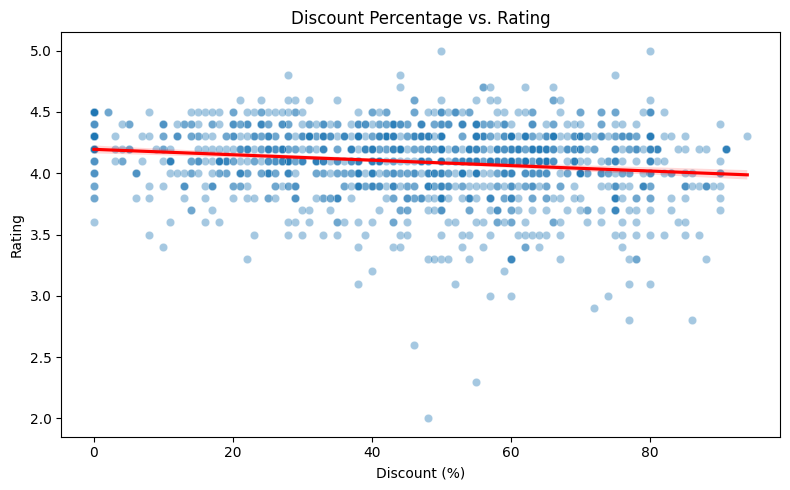

In [18]:
correlation = df['discount_percentage'].corr(df['rating'])
print(f"Correlation: {correlation:.3f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='discount_percentage', y='rating', alpha=0.4)
sns.regplot(data=df, x='discount_percentage', y='rating', scatter=False, color='red')
plt.title('Discount Percentage vs. Rating')
plt.xlabel('Discount (%)')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

Q1 Note:

Pearson's correlation: Near 0 = No relationship | 0.3 to 0.5 = Moderate | 0.7 to 1.0 = Strong Relationship

### Q1 Finding
**Finding:** Discount percentage has a weak/no correlation with product rating `(r = -0.162)`.  
**Implication:** Offering higher discounts does not guarantee better customer satisfaction. 
Amazon should not rely on discounting as a strategy to improve ratings.

## Q2 - Which categories have the highest average rating?

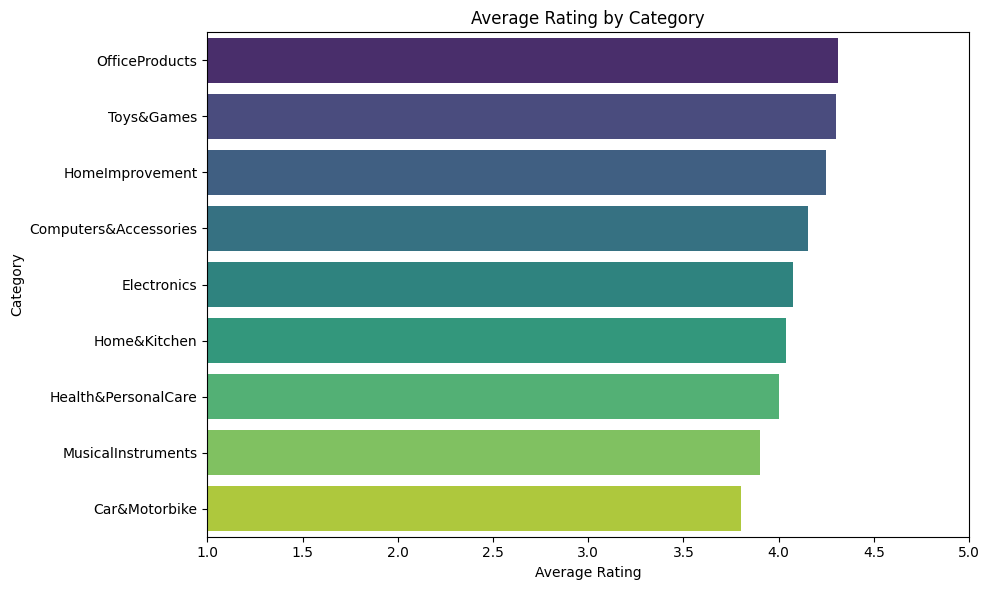

In [37]:
category_rating = (df.groupby('main_category')
                     ['rating'].mean()
                     .sort_values(ascending=False)
                     .reset_index())

plt.figure(figsize=(10, 6))
sns.barplot(data=category_rating, x='rating', y='main_category', palette='viridis', hue='main_category', legend=False)
plt.title('Average Rating by Category')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.xlim(1, 5) # Limit the scale of rating (1-5 stars)
plt.tight_layout()
plt.show()

### Q2 Finding

Finding: Office Product has the highest average rating while Car & Motorbike has the lowest average rating.  
Implication: Marketing team should inspect catagory which have below 4 average rating score. (Musical Instruments and Car & Mortobike, respectively) To improve the rating and after purchase services.

## Q3 - Are heavily discounted products reviewed more?

Correlation: 0.003


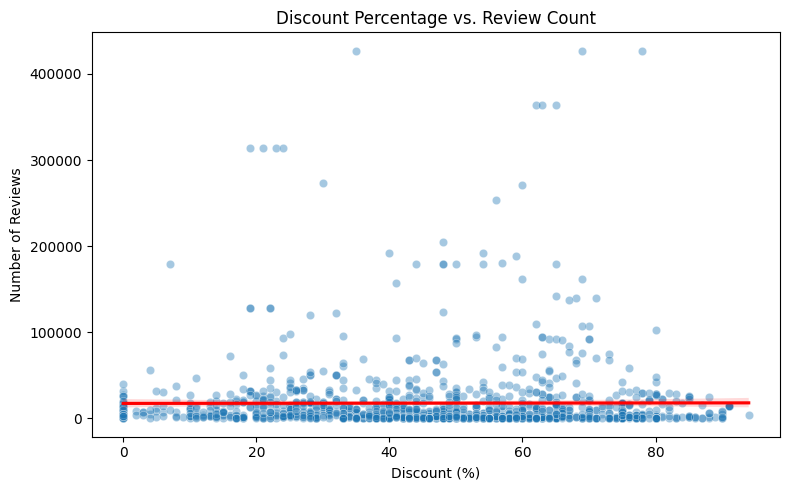

In [21]:
correlation = df['discount_percentage'].corr(df['rating_count'])
print(f"Correlation: {correlation:.3f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='discount_percentage', y='rating_count', alpha=0.4)
sns.regplot(data=df, x='discount_percentage', y='rating_count', scatter=False, color='red')
plt.title('Discount Percentage vs. Review Count')
plt.xlabel('Discount (%)')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

### Q3 Finding

Finding: Discount percentage has a weak/no correlation with Number of Reviews rating `(r = 0.003)`.  
Implication: Higher discounts do not drive more customer engagement. Discounting alone is not an effective strategy to increase review volume.

## Q4 - Does actual price affect rating?

Correlation: 0.128


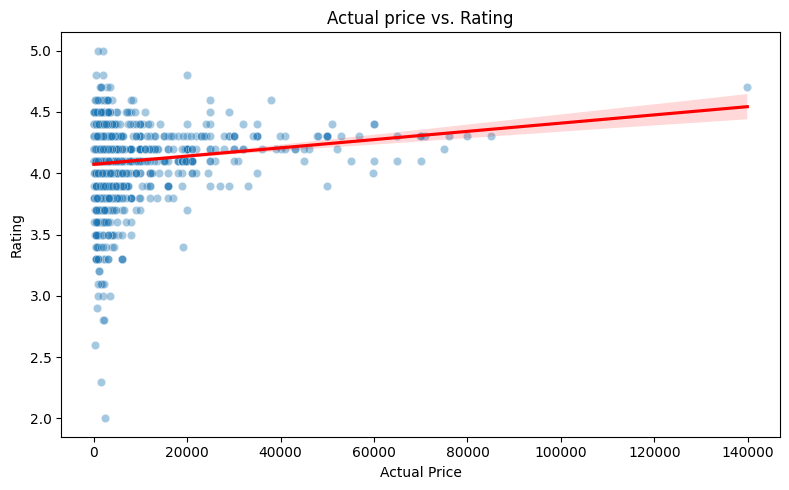

In [ ]:
correlation = df['actual_price'].corr(df['rating'])
print(f"Correlation: {correlation:.3f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='actual_price', y='rating', alpha=0.4)
sns.regplot(data=df, x='actual_price', y='rating', scatter=False, color='red')
plt.title('Actual Price vs. Rating')
plt.xlabel('Actual Price')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

### Q4 Finding

Finding: Actual price has a weak correlation with rating `(r = 0.128)`.  
Implication: Higher prices do not guarantee higher ratings. Don't be afraid of lower price points. Since low-priced items are capable of achieving top-tier ratings, the business can successfully compete on "Value for Money." Customers aren't necessarily rating items poorly just because they are cheap.

## Q5 - Which categories get the most reviews?

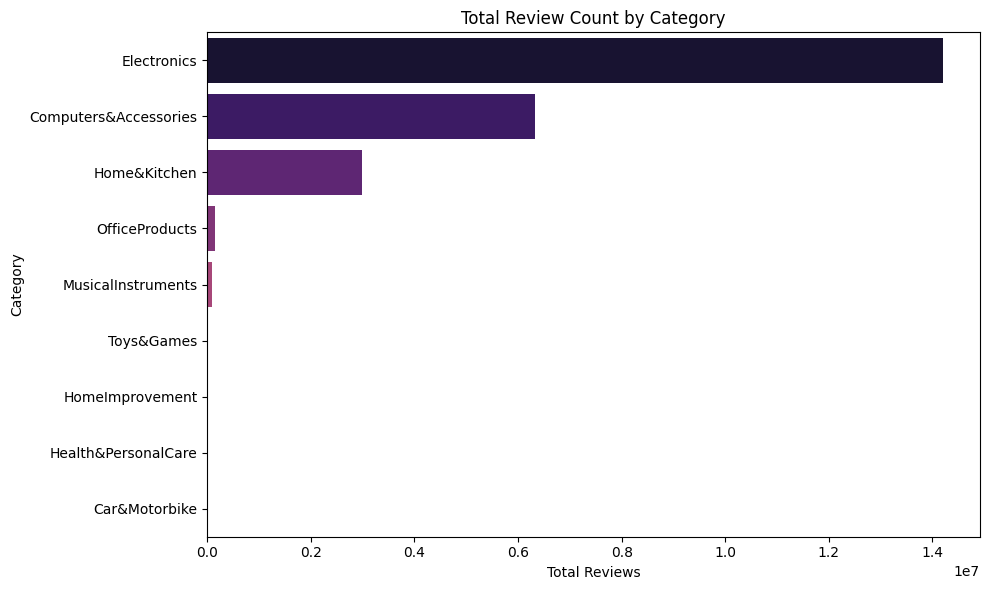

In [36]:
category_reviews = (df.groupby('main_category')
                     ['rating_count'].sum()
                     .sort_values(ascending=False)
                     .reset_index())

plt.figure(figsize=(10, 6))
sns.barplot(data=category_reviews, x='rating_count', y='main_category', palette='magma', hue='main_category', legend=False)
plt.title('Total Review Count by Category')
plt.xlabel('Total Reviews')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

### Q5 Finding

Finding: Electronics category has the highest total reviews where Car & Motorbike category has the lowest.  
Implication: Business need to find out what's happen with Office Procuct, Music Instruments, Toys & Games, Home Improvement, Health & Personal Care, and Car & Motorbike has lower total review significantly.

# Share

## Key Findings Summary

| # | Business Question | Finding | r-value |
|---|---|---|---|
| 1 | Does discount drive higher ratings? | Weak negative - discounts slightly associate with lower ratings | -0.162 |
| 2 | Which categories rate highest? | Office Products (#1), Car & Motorbike (#last, below 4.0) | N/A |
| 3 | Do discounts drive more reviews? | No relationship - discounts don't increase engagement | 0.003 |
| 4 | Does price affect rating? | Weak positive - price is not a quality signal | 0.128 |
| 5 | Which categories get the most reviews? | Electronics dominates; Office Products is highly rated but underexposed | N/A |

### 🔑 Overall Insight
Amazon's discount strategy has minimal impact on both customer satisfaction and 
engagement. Product quality — not price or discount — is the primary driver of ratings. 
Categories like Office Products represent an underexposed opportunity: top-rated but 
low in review volume, suggesting a marketing gap rather than a quality problem. 
Categories scoring below 4.0 (Car & Motorbike, Musical Instruments) warrant 
post-purchase service improvements.

# Act

## Business Recommendation

### Rec 1 — Rethink Discount Strategy
**Action:** Stop using blanket discounting as a tool to improve product ratings.  
**Evidence:** Discount % shows a weak negative correlation with rating (r = -0.162).  
**Next Step:** Audit the top 20% most-discounted products — are they also the lowest rated?  
If yes, the discounting may be masking a product quality problem.

### Rec 2 — Improve Underperforming Categories
**Action:** Prioritize after-purchase service improvements for Car & Motorbike   
and Musical Instruments (both average below 4.0 stars).
**Evidence:** These are the lowest-rated categories in the dataset.  
**Next Step:** Conduct customer complaint analysis for these two categories 
to identify the root cause (shipping damage? product quality? misleading listings?).  

### Rec 3 — Invest in Organic Review Growth
**Action:** Replace discount-driven campaigns with review-incentive programs
(e.g., follow-up emails, loyalty points for leaving reviews).  
**Evidence:** Discounts have near-zero correlation with review count (r = 0.003).  
**Next Step:** A/B test a post-purchase email campaign vs. a discount campaign 
and compare review volume outcomes.  

### Rec 4 — Market Low-Price Items as "Value for Money"
**Action:** Reframe marketing messaging for budget products to emphasise quality 
and value rather than competing purely on price.  
**Evidence:** Actual price has only a weak correlation with rating (r = 0.128) — 
cheap products achieve top ratings just as often.  
**Next Step:** Identify the top 10 highest-rated products under ₹500 and 
feature them in a "Best Value" collection.  

### Rec 5 — Boost Visibility for Office Products
**Action:** Increase marketing investment and sponsored placements for 
Office Products category.  
**Evidence:** Office Products has the highest average rating but very low review 
count — a classic hidden gem problem.  
**Next Step:** Launch a targeted campaign to drive traffic to this category 
and generate more reviews to build social proof.  

### ⚠️ Limitations
- Dataset is a static snapshot (~1,465 products) — trends over time cannot be assessed
- Data is scraped, not sourced directly from Amazon — some values may be inaccurate
- No demographic or geographic data — regional differences cannot be explored
- Correlation ≠ causation — discount strategy may not directly *cause* rating changes